In [1]:
import pickle # save and load python objects
import json # stores and reads data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # builds untop a matplotlib and maks certain statistical plot easier

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

tf.random.set_seed(42)
np.random.seed(42)  # seed mean random numbers that don't change each time you run the code 

<h1>load dataset</h1>
<h1>train, validate and test the data loaded</h1>

In [2]:
train_df = pd.read_csv('malaria_train.csv')
val_df = pd.read_csv('malaria_val.csv')  
test_df = pd.read_csv('malaria_test.csv')

X_train = train_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
Y_train = train_df['Malaria_Positive'].values.astype(np.float32)

X_val = val_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
Y_val = val_df['Malaria_Positive'].values.astype(np.float32)

X_test = test_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
Y_test = test_df['Malaria_Positive'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")

Train: (560, 15)
Val: (120, 15)
Test: (120, 15)
Number of features: 15


In [3]:
print(f"Train: {train_df.columns}")
print(f"Val: {val_df.columns}")
print(f"Test: {test_df.columns}")

Train: Index(['Age', 'Fever_Temp', 'Chills', 'Headache_Severity', 'Vomiting',
       'Diarrhea', 'Muscle_Pain', 'Fatigue_Level', 'Sweating', 'Nausea',
       'High_Fever', 'Fever_x_Chills', 'Severe_Headache', 'Symptom_Count',
       'Vulnerable_Age', 'Malaria_Positive'],
      dtype='object')
Val: Index(['Age', 'Fever_Temp', 'Chills', 'Headache_Severity', 'Vomiting',
       'Diarrhea', 'Muscle_Pain', 'Fatigue_Level', 'Sweating', 'Nausea',
       'High_Fever', 'Fever_x_Chills', 'Severe_Headache', 'Symptom_Count',
       'Vulnerable_Age', 'Malaria_Positive'],
      dtype='object')
Test: Index(['Age', 'Fever_Temp', 'Chills', 'Headache_Severity', 'Vomiting',
       'Diarrhea', 'Muscle_Pain', 'Fatigue_Level', 'Sweating', 'Nausea',
       'High_Fever', 'Fever_x_Chills', 'Severe_Headache', 'Symptom_Count',
       'Vulnerable_Age', 'Malaria_Positive'],
      dtype='object')


In [4]:
print(val_df.shape)
print(val_df.columns.tolist())

(120, 16)
['Age', 'Fever_Temp', 'Chills', 'Headache_Severity', 'Vomiting', 'Diarrhea', 'Muscle_Pain', 'Fatigue_Level', 'Sweating', 'Nausea', 'High_Fever', 'Fever_x_Chills', 'Severe_Headache', 'Symptom_Count', 'Vulnerable_Age', 'Malaria_Positive']


In [5]:
df = pd.read_csv('malaria_train.csv')

print(f"Shape:         {df.shape}")
print(f"Duplicates:    {df.duplicated().sum()}")
print(f"Missing (NaN): {df.isnull().sum().sum()}")

df.head()


Shape:         (560, 16)
Duplicates:    0
Missing (NaN): 0


,Age,Fever_Temp,Chills,Headache_Severity,Vomiting,Diarrhea,Muscle_Pain,Fatigue_Level,Sweating,Nausea,High_Fever,Fever_x_Chills,Severe_Headache,Symptom_Count,Vulnerable_Age,Malaria_Positive
0,-0.097152,1.521322,1.150500,0.483976,-0.571852,-0.486007,0.843639,1.218079,1.220200,1.501937,1.352140,1.199278,-0.511137,1.013310,-0.242077,1.0
1,0.179718,-1.102725,-0.869187,0.292438,-0.571852,-0.486007,-0.147628,-0.793208,-0.819538,-0.665807,-0.739568,-0.868696,-0.511137,-1.122651,-0.242077,0.0
2,-1.066194,-0.033670,-0.869187,-1.086637,-0.571852,-0.486007,-1.456100,-0.011041,-0.819538,1.501937,-0.739568,-0.868696,-0.511137,-0.410664,-0.242077,0.0
3,0.664239,-0.422416,-0.869187,-1.163252,-0.571852,-0.486007,-0.900991,0.696634,-0.819538,-0.665807,-0.739568,-0.868696,-0.511137,-1.122651,-0.242077,0.0
4,-0.166369,1.035388,1.150500,0.560591,1.748706,2.057582,1.041893,1.665032,1.220200,-0.665807,1.352140,1.172901,-0.511137,1.725298,-0.242077,1.0


In [6]:
with open("malaria_train.json") as f:
    data = json.load(f) 
df=pd.DataFrame(data)
target = "Malaria_Positive"
feature = [
    col for col in df.columns
    if col != target
]
X = df[feature].values.astype(np.float32)
Y = df[target].values.astype(np.float32)

print("Loaded malaria dataset")
print(f"Number and features: {len(feature)}")
print(f"Features: {feature}")
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

Loaded malaria dataset
Number and features: 15
Features: ['Age', 'Fever_Temp', 'Chills', 'Headache_Severity', 'Vomiting', 'Diarrhea', 'Muscle_Pain', 'Fatigue_Level', 'Sweating', 'Nausea', 'High_Fever', 'Fever_x_Chills', 'Severe_Headache', 'Symptom_Count', 'Vulnerable_Age']
X shape: (560, 15)
Y shape: (560,)


In [7]:
def build_ann(n_features):
    inputs = keras.Input(shape=(n_features,), name='features')


    
    # block 1
    x = keras.layers.Dense(128, kernel_regularizer= keras.regularizers.l2(1e-4))(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    # block 2
    x = keras.layers.Dense(32)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    #block 3
    x = keras.layers.Dense(32)(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    #output: a single probability
    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(x)
    return keras.models.Model(inputs, outputs, name='MalariaANN')

model = build_ann(X_train.shape[1])
model.summary()

Model: "MalariaANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 15)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,905 (30.88 KB)

 Trainable params: 7,585 (29.63 KB)

 Non-trainable params: 320 (1.25 KB)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=10,
        restore_best_weights=True, mode='max', verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=10,
        min_lr=1e-6, mode='max', varbose=1),
    keras.callbacks.ModelCheckpoint(
        'best_malaria.keras', monitor='val_auc',
        save_best_only=True, mode='max', verbose=0),
]

history = model.fit(
    X_train, Y_train,
    epochs=300, batch_size=35,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEpochs run: (len(history.history['loss']))")
print(f"Best val AUC: {max(history.history['val_auc']):.4f}")

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.4786 - auc: 0.6802 - loss: 0.7935 - precision: 0.4389 - recall: 0.9099 - val_accuracy: 0.7250 - val_auc: 0.9791 - val_loss: 0.5927 - val_precision: 0.6024 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6625 - auc: 0.8530 - loss: 0.6026 - precision: 0.5561 - recall: 0.9356 - val_accuracy: 0.8917 - val_auc: 0.9964 - val_loss: 0.5116 - val_precision: 0.7937 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8179 - auc: 0.9485 - loss: 0.4568 - precision: 0.7120 - recall: 0.9442 - val_accuracy: 0.9250 - val_auc: 0.9989 - val_loss: 0.4485 - val_precision: 0.8475 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8714 - auc: 0.9690 - loss: 0.3882 - precision: 0.7825 - recall: 0.9571 - val_accuracy: 0.9667 - val_auc: 0.9989 - val_loss: 

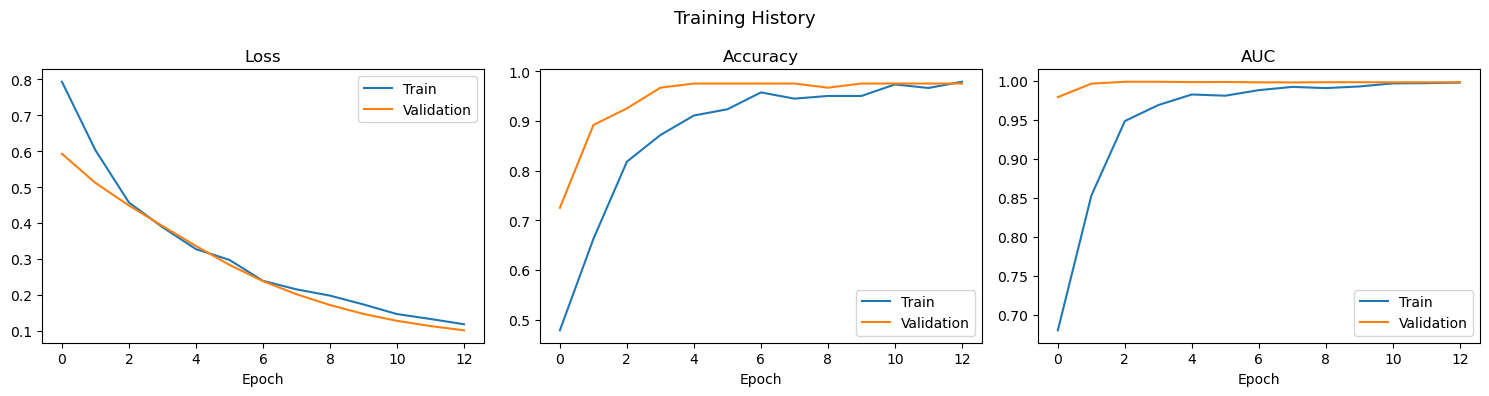

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('house_price_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
model.load_weights('best_malaria.keras')

test_results = model.evaluate(X_test, Y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"{name:<12}: {value:.4f}")

loss        : 0.4278
compile_metrics: 0.9833


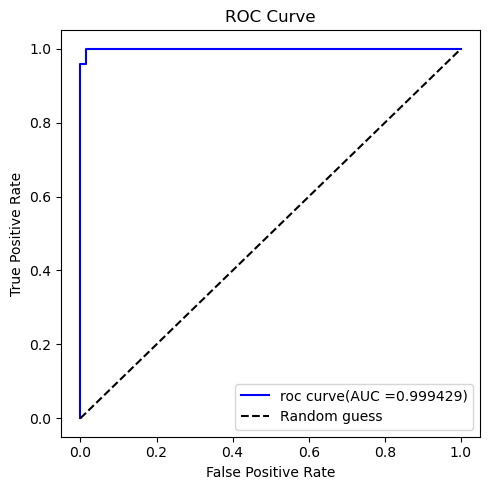

ROC-AUC: 0.9994


In [12]:
Y_prob = model.predict(X_test, verbose=0).flatten()
auc_score = roc_auc_score(Y_test, Y_prob)

fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='blue', label=f'roc curve(AUC ={auc_score:2f})')
plt.plot([0,1],[0,1], color='black', linestyle='--', label="Random guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

  No Malaria       1.00      0.97      0.99        70
     Malaria       0.96      1.00      0.98        50

    accuracy                           0.98       120
   macro avg       0.98      0.99      0.98       120
weighted avg       0.98      0.98      0.98       120



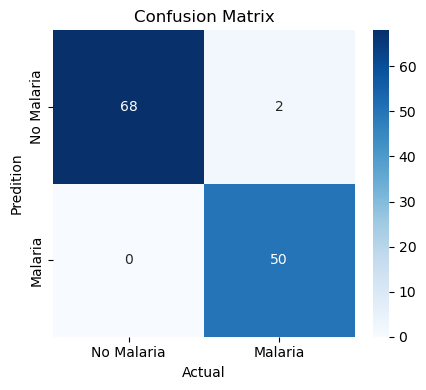

In [13]:
Y_pred = (Y_prob >= 0.5).astype(int)
import seaborn as sns

print(classification_report(Y_test, Y_pred, target_names=['No Malaria', 'Malaria']))

cm=confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No Malaria', 'Malaria'],
           yticklabels=['No Malaria', 'Malaria'])
plt.xlabel('Actual')
plt.ylabel('Predition')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
model.save('malaria_ann.keras')
with open('malaria_inference_kit.pkl', 'wb') as f:
    pickle.dump({
        'feature': feature,
    }, f)
print('saved malaria_ann.keras')
print('saved malaria_inference_kit.pkl')

saved malaria_ann.keras
saved malaria_inference_kit.pkl
